# Darts — Time Series Forecasting Practice

This notebook provides a **hands-on introduction** to **Darts**, a Python library for time series analysis and forecasting developed by Unit8.

Darts offers a unified API to work with time series data and includes a wide range of models:

- Classical statistical models (Naive, Exponential Smoothing, ARIMA, Theta)
- Machine learning models (XGBoost, Regression models)
- Deep learning models (RNN, LSTM, TFT, N-BEATS, etc.)

The library simplifies the full forecasting workflow:

> data preparation → `TimeSeries` abstraction → model training → forecasting → evaluation

---

**Datasets used**

- Built-in dataset from Darts
    - AirPassengersDataset — classic monthly airline passenger counts (1949–1960)

- External real-world datasets (from Kaggle)
    - Time Series Datasets (Kaggle, by shenba):
    - Electric_Production.csv
    - daily-minimum-temperatures-in-me.csv
    - monthly-beer-production-in-austr.csv
    - sales-of-shampoo-over-a-three-ye.csv

These datasets cover different characteristics:
- Trend
- Seasonality
- Noise
- Different time granularities (daily, monthly)

In [2]:
!pip install darts --quiet

# Imports & Loads Data

In [1]:
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from darts import TimeSeries
from darts.datasets import AirPassengersDataset
from darts.models import (
    NaiveSeasonal,
    NaiveDrift,
    ExponentialSmoothing,
    RNNModel,
    ARIMA,
    AutoARIMA,
    Theta,
    XGBModel,
)
from darts.dataprocessing.transformers import Scaler
from darts.metrics import mape, rmse, mae

Support for PyTorch based likelihood models not available. To enable them, install "darts[torch]" or "darts[all]" (with pip); or "u8darts-torch" or "u8darts-all" (with conda).
Support for Torch based models not available. To enable them, install "darts[torch]" or "darts[all]" (with pip); or "u8darts-torch" or "u8darts-all" (with conda).
The StatsForecast module could not be imported. To enable support for the AutoARIMA, AutoETS and Croston models, please consider installing it.


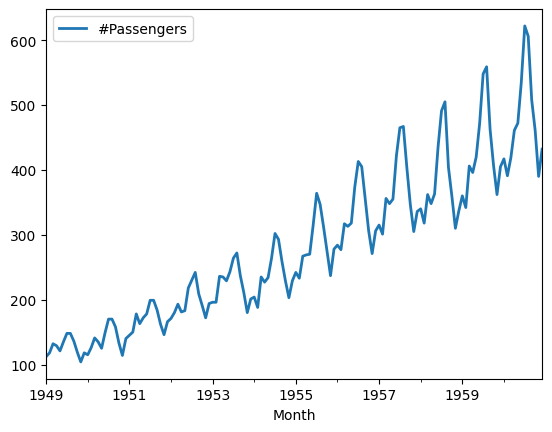

,#Passengers
Month,
1949-01-01,112.0
1949-02-01,118.0
1949-03-01,132.0
1949-04-01,129.0
1949-05-01,121.0
...,...
1960-08-01,606.0
1960-09-01,508.0
1960-10-01,461.0


In [2]:
air_series = AirPassengersDataset().load()
air_series.plot()
plt.show()
air_series

## Building and Manipulating `TimeSeries`

`TimeSeries` is the core data structure in Darts. It represents a univariate or multivariate time series with an associated time index.

The time index can be:
- `pandas.DatetimeIndex` — for real timestamps
- `pandas.RangeIndex` — for sequential data without explicit dates

`TimeSeries` can also represent *probabilistic* series (e.g., for confidence intervals).  
All Darts models **consume** `TimeSeries` and **produce** `TimeSeries`.

`TimeSeries` can be created using several convenient factory methods:

- `TimeSeries.from_dataframe()` — from a full Pandas DataFrame  
- `TimeSeries.from_times_and_values()` — from time index + values  
- `TimeSeries.from_values()` — from a NumPy array  
- `TimeSeries.from_series()` — from a Pandas Series  
- `TimeSeries.from_xarray()` — from an xarray DataArray  
- `TimeSeries.from_csv()` — directly from a CSV file  
- `TimeSeries.from_group_dataframe()` — create multiple series grouped from a DataFrame

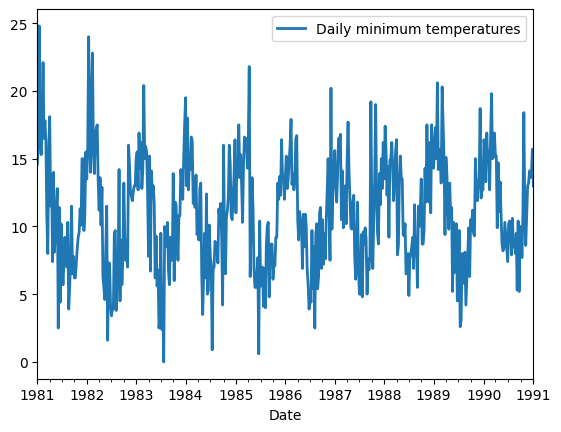

,Daily minimum temperatures
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8
1981-01-04,14.6
1981-01-05,15.8
...,...
1990-12-27,14.0
1990-12-28,13.6
1990-12-29,13.5


In [3]:
from mlpeople.time_series.io import read_df,read_shampoo_df

temperature_df = read_df("daily-minimum-temperatures-in-me.csv", datetime_col="Date")
electric_df = read_df("Electric_Production.csv", datetime_col="DATE")
beer_df = read_df("monthly-beer-production-in-austr.csv", datetime_col="Month")
shampoo_df = read_shampoo_df("sales-of-shampoo-over-a-three-ye.csv")

temperature_series = TimeSeries.from_dataframe(
    temperature_df,
    value_cols='Daily minimum temperatures',
    fill_missing_dates=True,
    freq='D'
)
electric_series = TimeSeries.from_dataframe(
    electric_df,
    value_cols='IPG2211A2N',
    fill_missing_dates=True,
    freq='MS'
)

beer_series = TimeSeries.from_dataframe(
    beer_df,
    value_cols='Monthly beer production',
    fill_missing_dates=True,
    freq='MS'
)

shampoo_series = TimeSeries.from_dataframe(
    shampoo_df,
    value_cols='Sales of shampoo over a three year period',
    fill_missing_dates=True,
    freq='MS'
)

# display temperature with resample per week of year
temperature_series.resample('W').mean().plot()
plt.show()
temperature_series

# `TimeSeries` Operations

`TimeSeries` supports various operations. Here are some examples.

---

**Split**

A `TimeSeries` can be split into training and validation (or any two parts) in multiple ways:

- By **pandas `Timestamp`**
- By **integer index**

This is useful for creating **train/validation sets** for forecasting models.

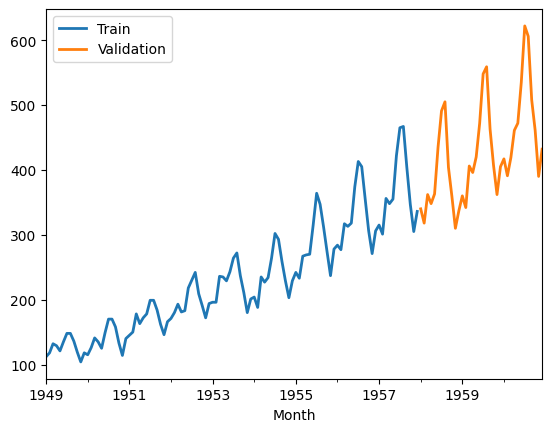

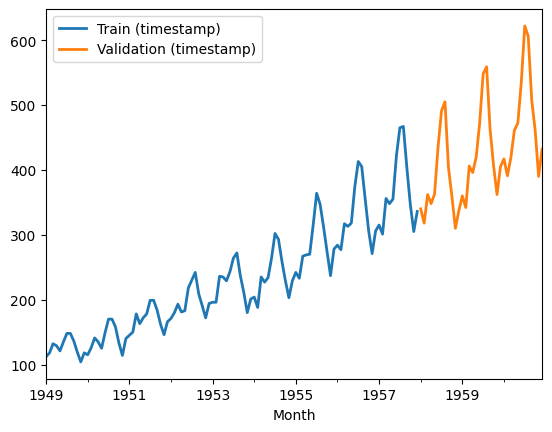

In [4]:
# Split by fraction of series length
air_series_train, air_series_val = air_series.split_after(0.75)

# Plot with labels
air_series_train.plot(label='Train')
air_series_val.plot(label='Validation')
plt.legend()
plt.show()

# Split by timestamp (example)
split_time = pd.Timestamp('1958-01-01')
train_ts, val_ts = air_series.split_before(split_time)

train_ts.plot(label='Train (timestamp)')
val_ts.plot(label='Validation (timestamp)')
plt.legend()
plt.show()

**slicing:**

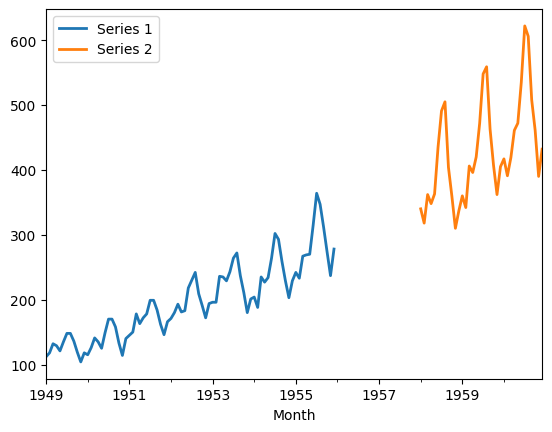

In [5]:
# Slicing

# You can slice a TimeSeries using Python-style indexing
# Example: split the series into two parts
series1 = air_series[:-60]  # all except the last 60 points
series2 = air_series[-36:]  # last 36 points

# Plot with labels
series1.plot(label='Series 1')
series2.plot(label='Series 2')
plt.legend()
plt.show()

**arithmetic operations:**

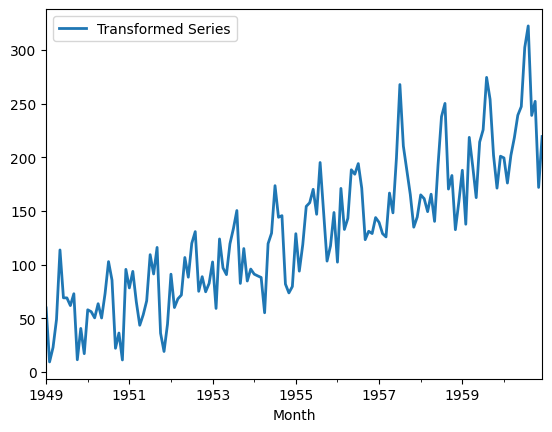

In [6]:
# Arithmetic Operations

# You can perform element-wise arithmetic with TimeSeries
# Examples: addition, subtraction, multiplication, division

# Create a random noise series with the same index as air_series
series_noise = TimeSeries.from_times_and_values(
    air_series.time_index, np.random.randn(len(air_series))
)

# Example operation: scale, add noise, and shift
result_series = (air_series / 2 + 20 * series_noise - 10)

# Plot the result
result_series.plot(label='Transformed Series')
plt.legend()
plt.show()

**stacking:**

Combine multiple series into a single multi-dimensional TimeSeries.

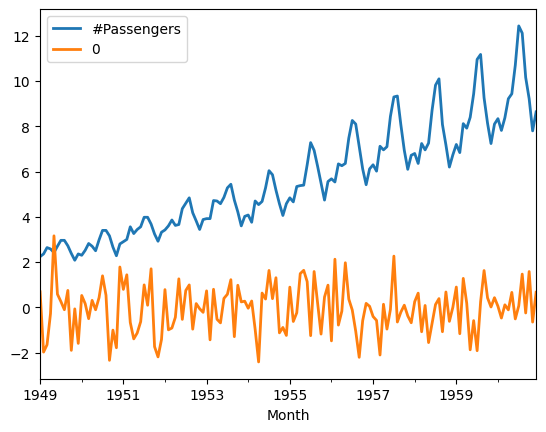

In [7]:
# Stacking / Multi-dimensional Series

# You can combine two or more TimeSeries into a single multi-dimensional series
# using the `stack()` method. This is useful when your models expect
# multivariate inputs.

# Example: scale air_series and combine with random noise
multi_series = (air_series / 50).stack(series_noise)

# Plot the multi-dimensional series
multi_series.plot()
plt.show()

**mapping:**

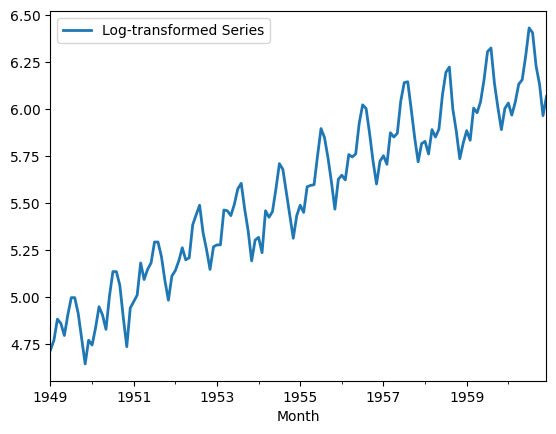

In [8]:
# Mapping / Element-wise Transformations

# You can apply any function element-wise to a TimeSeries using `.map()`
# Example: apply natural logarithm
log_series = air_series.map(np.log)

# Plot the result
log_series.plot(label='Log-transformed Series')
plt.legend()
plt.show()

**Adding some date and time attribute as an additional dimension (obtaining a multidimensional series):**

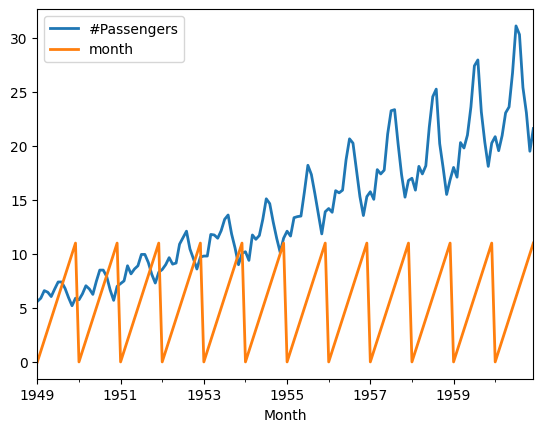

In [9]:
# Adding Date/Time Attributes as Additional Dimensions

# You can extract datetime features (e.g., month, day of week) and
# add them as extra dimensions to a TimeSeries using `.add_datetime_attribute()`.
# This produces a multi-dimensional series suitable for models that can use covariates.

# Example: scale air_series and add "month" as an additional dimension
multi_series_with_month = (air_series / 20).add_datetime_attribute("month")

# Plot the result
multi_series_with_month.plot()
plt.show()

**Adding some binary holiday components:**

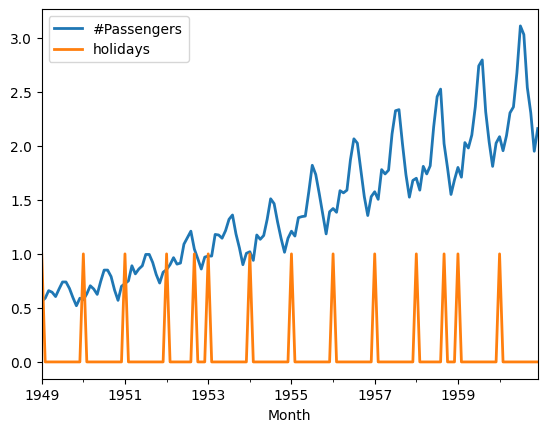

In [10]:
# Adding Binary Holiday Components

# You can add holiday indicators as extra dimensions using `.add_holidays()`.
# This creates a multi-dimensional TimeSeries with 1 for holidays and 0 otherwise.
# Useful for models that can use covariates to capture holiday effects.

# Example: scale air_series and add US holidays
multi_series_with_holidays = (air_series / 200).add_holidays("US")

# Plot the result
multi_series_with_holidays.plot()
plt.show()

**differencing:**

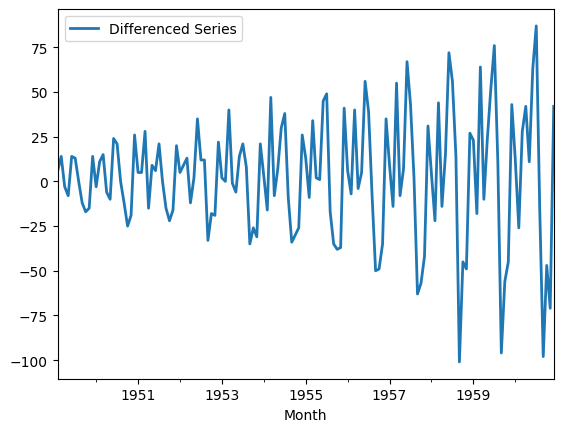

In [11]:
# Differencing

# Differencing subtracts the previous value from each point in the series.
# It is commonly used to remove trends or stabilize variance in time series.

# Example: first-order difference
diff_series = air_series.diff()

# Plot the differenced series
diff_series.plot(label='Differenced Series')
plt.legend()
plt.show()

**Filling in missing values ​​(using the `utils` function).**

Missing values ​​are represented as `np.nan`.

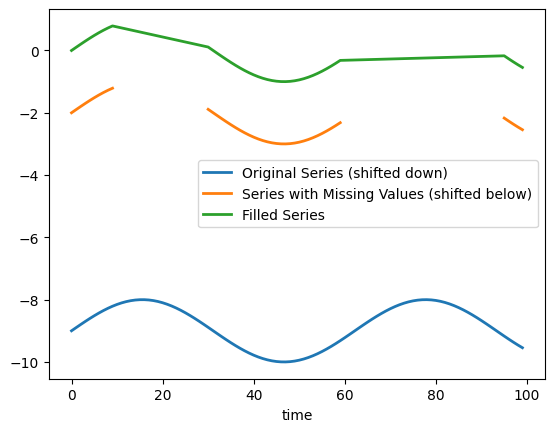

In [12]:
# Filling Missing Values

# Missing values in a TimeSeries are represented as np.nan.
# Darts provides `fill_missing_values()` to handle them.

from darts.utils.missing_values import fill_missing_values

# Create example series with missing values
original_values = np.sin(np.linspace(0, 10, 100))
values = original_values.copy()
values[10:30] = np.nan
values[60:95] = np.nan

series_ = TimeSeries.from_values(values)
original_series = TimeSeries.from_values(original_values)

# Plot
(original_series - 9).plot(label='Original Series (shifted down)')
(series_ - 2).plot(label='Series with Missing Values (shifted below)')
fill_missing_values(series_).plot(label='Filled Series')

plt.legend()
plt.show()

# Creating a training and validation series
For further steps, we will split our `TimeSeries` into a training and validation series

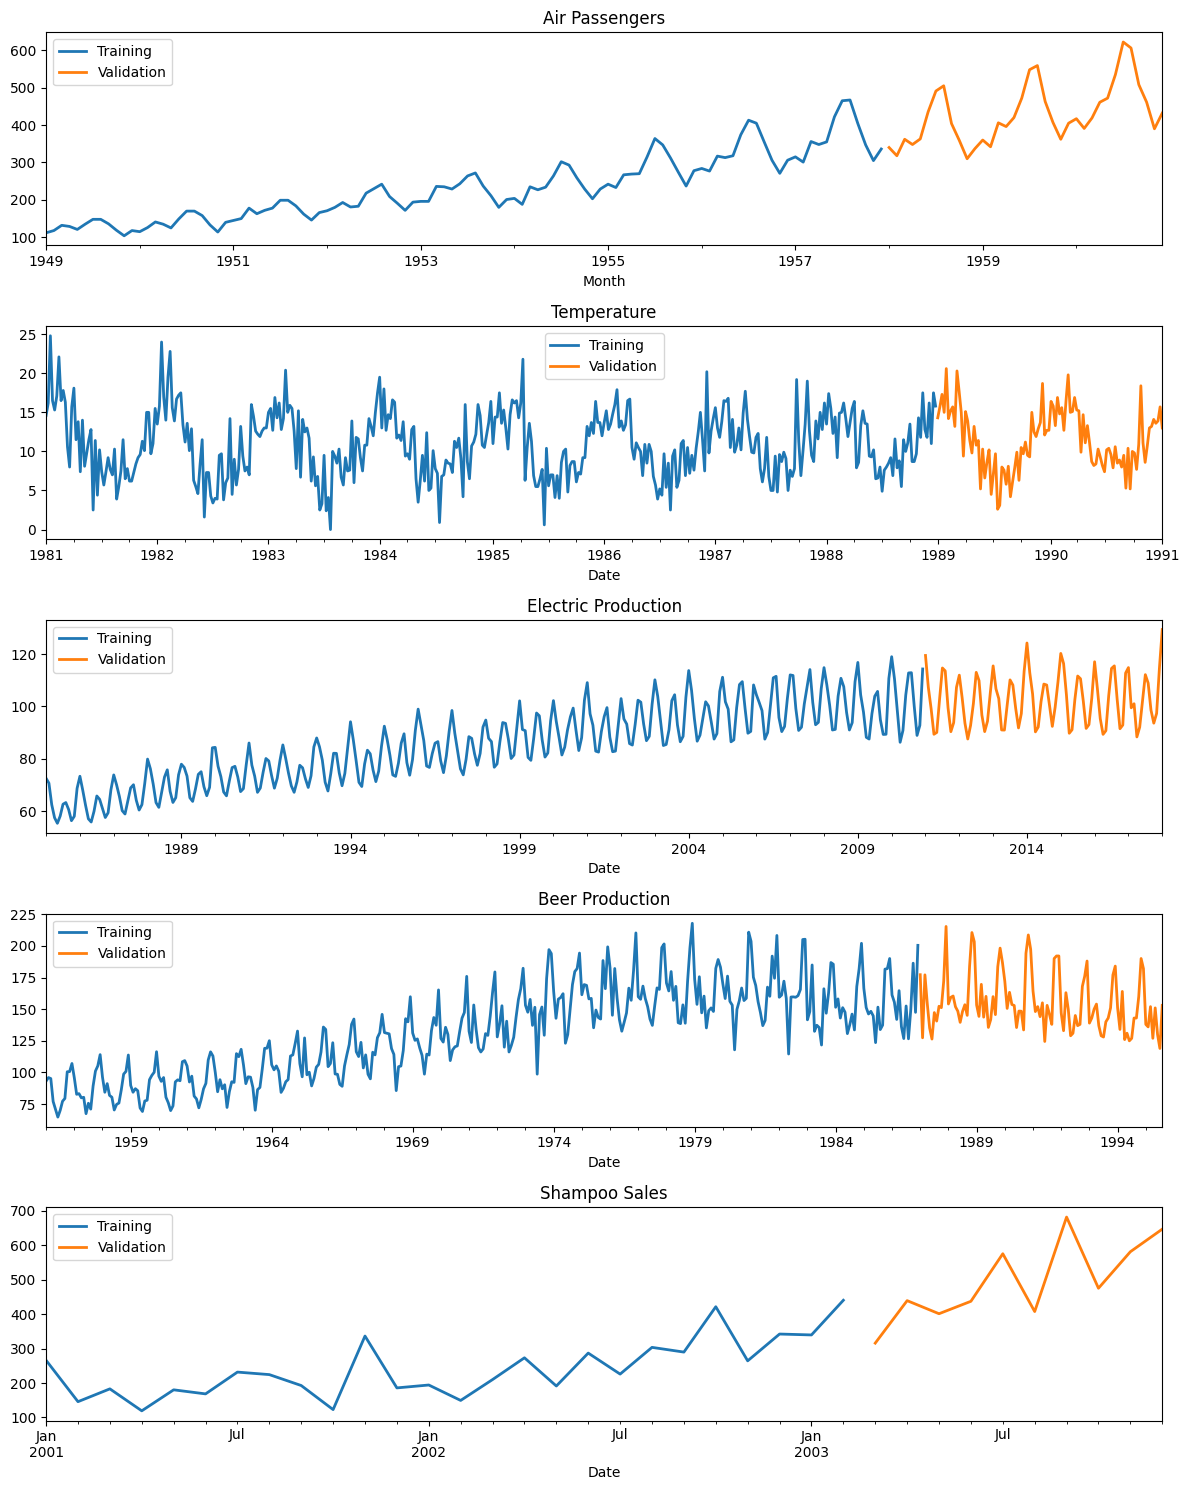

In [13]:
air_series_train, air_series_val = air_series.split_before(pd.Timestamp("1958-01-01"))

temperature_series_train, temperature_series_val = temperature_series.split_before(pd.Timestamp("1989-01-01"))

electric_series_train, electric_series_val = electric_series.split_before(pd.Timestamp("2011-01-01"))

beer_series_train, beer_series_val = beer_series.split_before(pd.Timestamp("1987-01-01"))

shampoo_series_train, shampoo_series_val = shampoo_series.split_before(0.75)

# Prepare data and titles
series_list = [
    (air_series_train, air_series_val, "Air Passengers"),
    (temperature_series_train.resample("W"), temperature_series_val.resample("W"), "Temperature"),
    (electric_series_train, electric_series_val, "Electric Production"),
    (beer_series_train, beer_series_val, "Beer Production"),
    (shampoo_series_train, shampoo_series_val, "Shampoo Sales")
]

# Create subplots
fig, axes = plt.subplots(len(series_list), 1, figsize=(12, 15), sharex=False)

for ax, (train, val, title) in zip(axes, series_list):
    train.plot(ax=ax, label='Training')
    val.plot(ax=ax, label='Validation')
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()

# Training Forecasting Models and Generating Predictions

Modern time series forecasting methods can capture complex patterns in data. Many of these are implemented in **Darts**.

**Common forecasting methods used in industry**
1. **Exponential Smoothing** — weights past observations exponentially for trend/seasonality.
2. **Theta** — decomposes a series into Theta lines and applies exponential smoothing to each.
3. **ARIMA / SARIMA** — classical statistical models for time series.
4. **Facebook Prophet** — handles seasonality and trends automatically.
5. **Recurrent Neural Networks (RNN, LSTM)** — deep learning models for sequential data.
6. **Transformers & Attention** — modern deep learning techniques for complex forecasting.

---

## Toy / Naive Models

Darts includes a collection of ["naive"](https://unit8co.github.io/darts/generated_api/darts.models.forecasting.global_baseline_models.html) baseline models to quickly assess minimal expected accuracy.

- Example: `NaiveSeasonal(K)` always repeats the value from `K` steps ago.  
- With `K=1`, it simply repeats the last value of the training series.

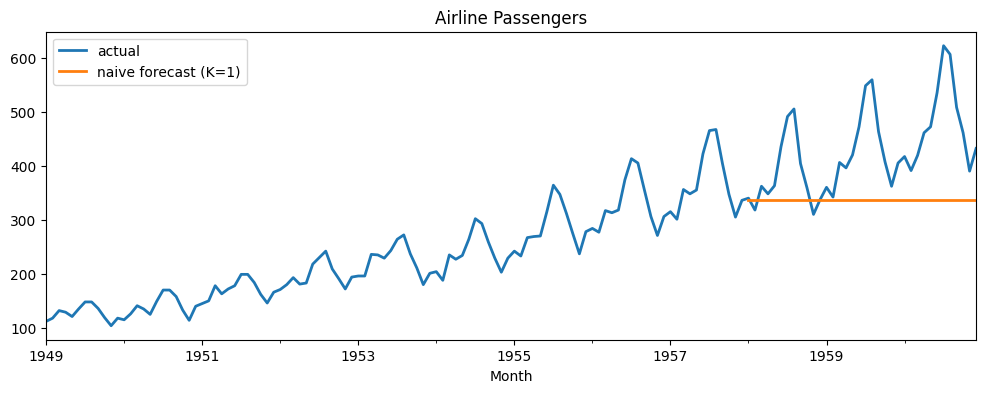

In [14]:
naive_model_air = NaiveSeasonal(K=1)
naive_model_air.fit(air_series_train)
naive_forecast_air = naive_model_air.predict(36)

plt.figure(figsize=(12, 4))
air_series.plot(label="actual")
naive_forecast_air.plot(label="naive forecast (K=1)")
plt.title("Airline Passengers")
plt.show()

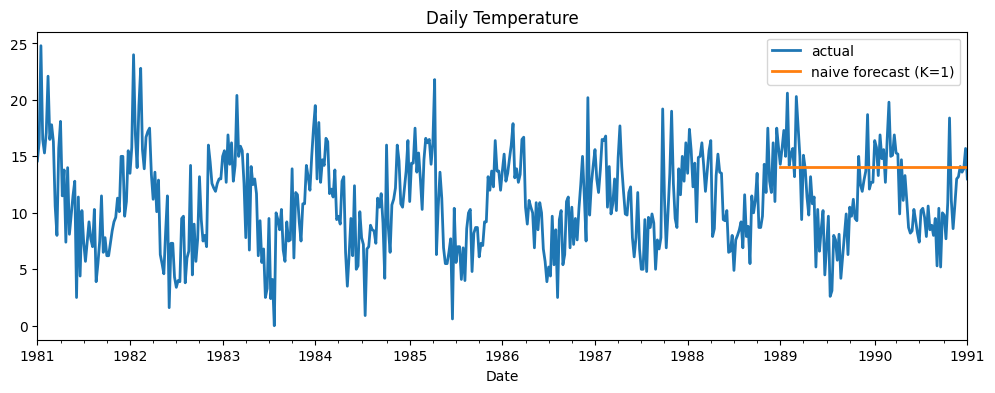

In [15]:
from darts.utils.missing_values import fill_missing_values

# fill missing values first to model work corrrectly
temperature_series_train = fill_missing_values(temperature_series_train)

# Fit NaiveSeasonal model
naive_model_temp = NaiveSeasonal(K=1)
naive_model_temp.fit(temperature_series_train)

# Predict next 2 years
naive_forecast_temp = naive_model_temp.predict(365*2)

plt.figure(figsize=(12, 4))
temperature_series.resample("W").plot(label="actual")
naive_forecast_temp.resample("W").plot(label="naive forecast (K=1)")
plt.legend()
plt.title("Daily Temperature")
plt.show()

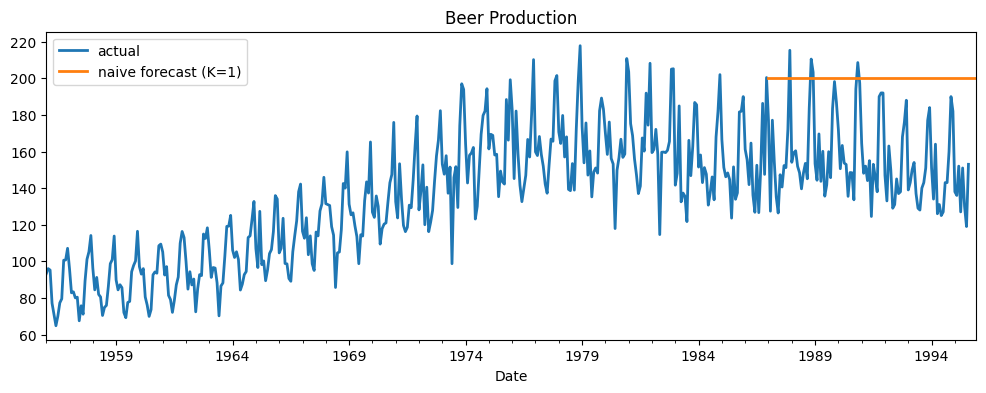

In [16]:
naive_model_beer = NaiveSeasonal(K=1)
naive_model_beer.fit(beer_series_train)

# predict 9 years
naive_forecast_beer = naive_model_beer.predict(9*12)

plt.figure(figsize=(12, 4))
beer_series.plot(label="actual")
naive_forecast_beer.plot(label="naive forecast (K=1)")
plt.title("Beer Production")
plt.show()

### Inspecting Seasonality

Our previous model may be a bit too naive.  
We can improve it by incorporating seasonality in the data.  

It is fairly obvious that the series has **annual seasonality**, which can be confirmed by examining the **autocorrelation function (ACF)**:  
- For **monthly data**, the seasonal lag is `m=12`  
- For **daily data**, the seasonal lag is `m=365`

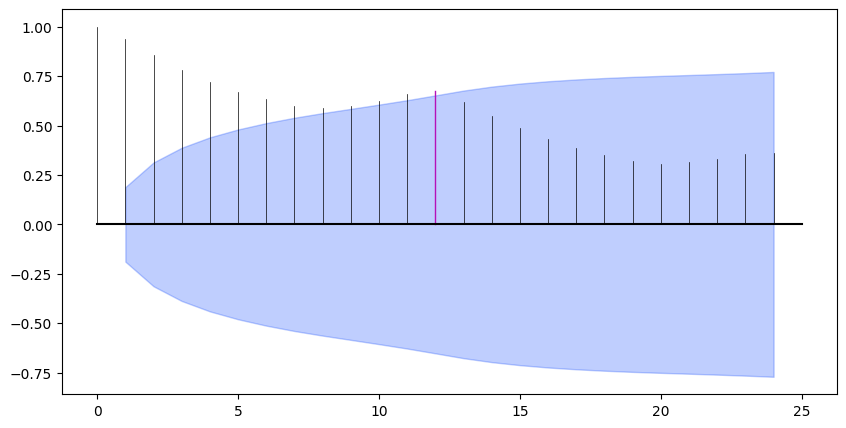

In [17]:
from darts.utils.statistics import plot_acf, check_seasonality

# Monthly data (AirPassengers)
plot_acf(air_series_train, m=12, alpha=0.05, max_lag=24)

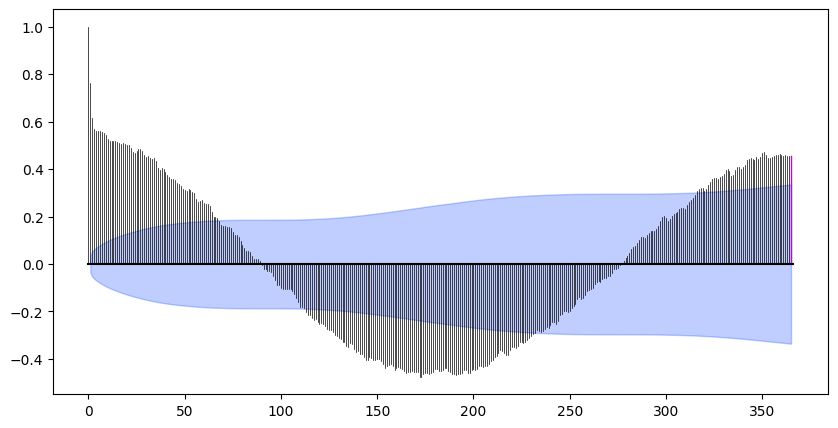

In [18]:
# Daily data (Temperature) — annual seasonality
plot_acf(temperature_series_train, m=365, alpha=0.05, max_lag=365)

In [19]:
for m in range(2, 25):
    is_seasonal, period = check_seasonality(air_series_train, m=m, alpha=0.05)
    if is_seasonal:
        print("There is seasonality for airline passengers of order {}.".format(period))

print('---\n')

for m in range(30, 366):
    is_seasonal, period = check_seasonality(
        temperature_series_train, m=m, alpha=0.05, max_lag=365
    )
    if is_seasonal:
        print(f"There is seasonality for daily temperature of order {period}.")

There is seasonality for airline passengers of order 12.
---

There is seasonality for daily temperature of order 31.
There is seasonality for daily temperature of order 34.
There is seasonality for daily temperature of order 38.
There is seasonality for daily temperature of order 44.
There is seasonality for daily temperature of order 52.
There is seasonality for daily temperature of order 59.
There is seasonality for daily temperature of order 62.
There is seasonality for daily temperature of order 73.
There is seasonality for daily temperature of order 288.
There is seasonality for daily temperature of order 292.
There is seasonality for daily temperature of order 299.
There is seasonality for daily temperature of order 308.
There is seasonality for daily temperature of order 318.
There is seasonality for daily temperature of order 325.
There is seasonality for daily temperature of order 332.
There is seasonality for daily temperature of order 338.
There is seasonality for daily tem

### Less Naive Model

Now, we improve the naive forecast by incorporating seasonality using **NaiveSeasonal**:  

- For **monthly data**, use `K=12` (annual seasonality)  
- For **daily data**, use `K=365` (yearly seasonality)

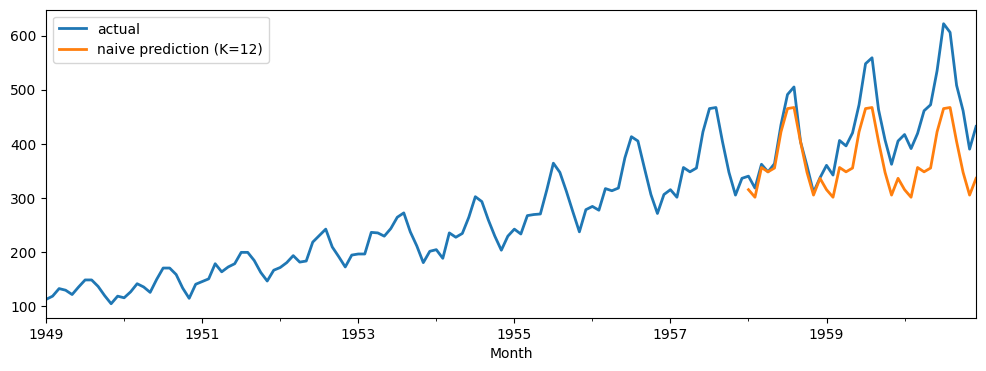

In [20]:
seasonal_model_air = NaiveSeasonal(K=12)
seasonal_model_air.fit(air_series_train)
seasonal_forecast_air = seasonal_model_air.predict(36)

plt.figure(figsize=(12, 4))
air_series.plot(label="actual")
seasonal_forecast_air.plot(label="naive prediction (K=12)")
plt.show()

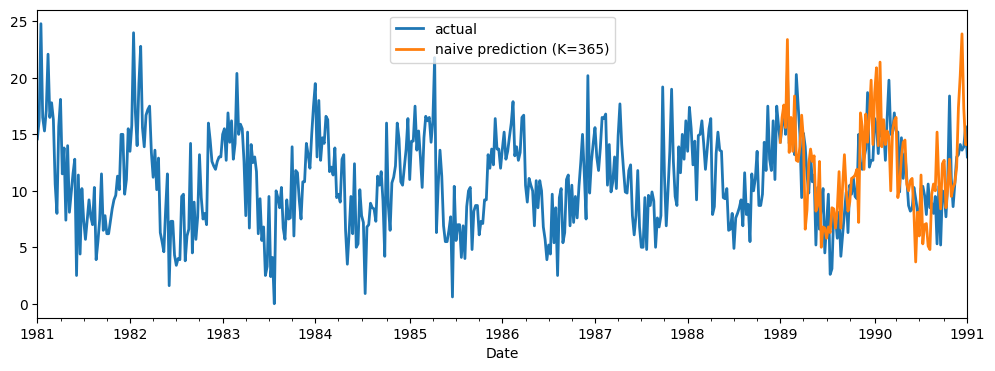

In [21]:
from darts.utils.missing_values import fill_missing_values

# fill missing values first to model work corrrectly
temperature_series_train = fill_missing_values(temperature_series_train)

# Fit NaiveSeasonal model
seasonal_model_temp = NaiveSeasonal(K=365)
seasonal_model_temp.fit(temperature_series_train)

# Predict next 2 years
seasonal_forecast_temp = seasonal_model_temp.predict(365*2)

plt.figure(figsize=(12, 4))
temperature_series.resample("W").plot(label="actual")
seasonal_forecast_temp.resample("W").plot(label="naive prediction (K=365)")
plt.legend()
plt.show()

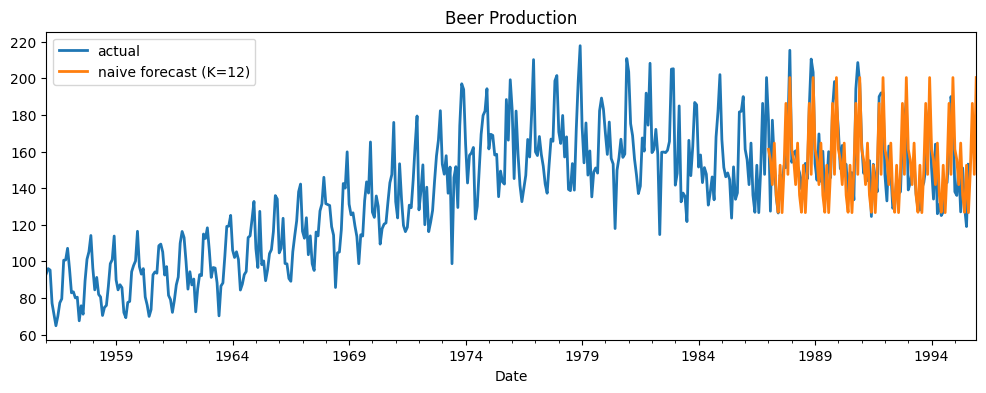

In [22]:
seasonal_model_beer = NaiveSeasonal(K=12)
seasonal_model_beer.fit(beer_series_train)

# predict 9 years
seasonal_forecast_beer = seasonal_model_beer.predict(9*12)

plt.figure(figsize=(12, 4))
beer_series.plot(label="actual")
seasonal_forecast_beer.plot(label="naive forecast (K=12)")
plt.title("Beer Production")
plt.show()

With annual seasonality, the forecast looks quite reasonable for **daily temperature** and **beer production**, but for **Airline Passengers** it clearly misses the trend.  

Fortunately, there is another naive baseline model that **captures the trend**: **NaiveDrift**.  
This model produces **linear predictions**, where the slope is determined by the **first and last values** of the training series.

### NaiveDrift to catch trend

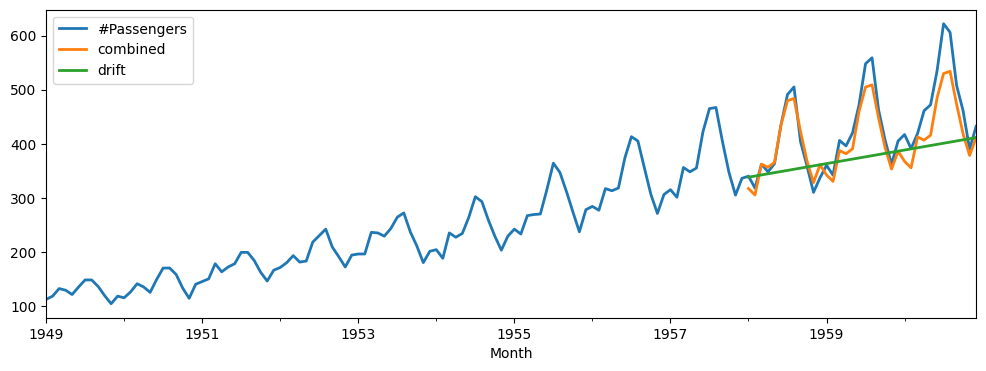

In [23]:
# Drift model
drift_model_air = NaiveDrift()
drift_model_air.fit(air_series_train)
drift_forecast_air = drift_model_air.predict(36)

# Combine drift + seasonal (trainded previously)
combined_forecast_air = drift_forecast_air + seasonal_forecast_air - air_series_train.last_value()

# Plot
plt.figure(figsize=(12, 4))
air_series.plot()
combined_forecast_air.plot(label="combined")
drift_forecast_air.plot(label="drift")
plt.show()

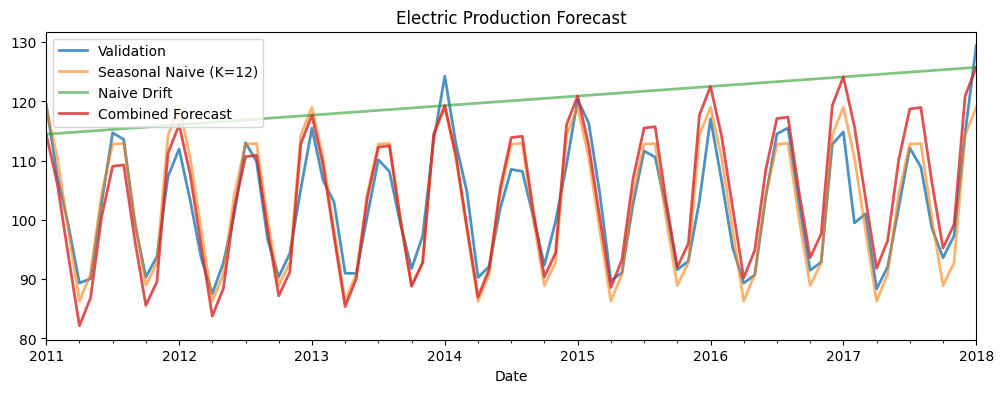

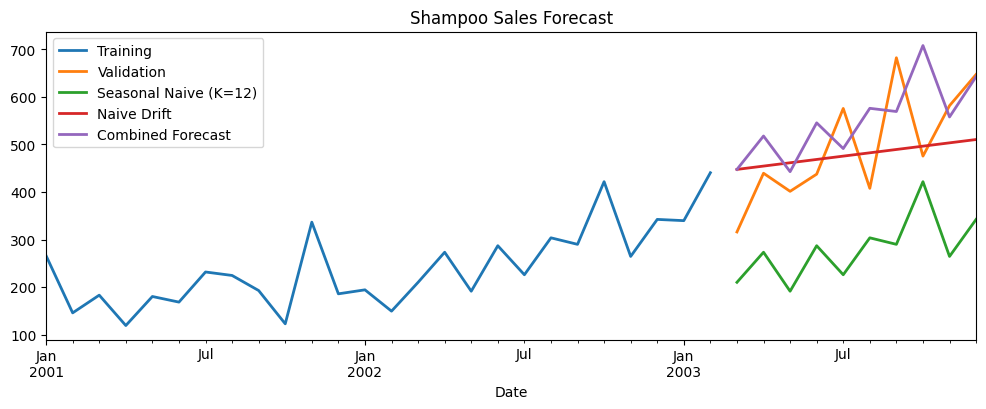

In [24]:
# -----------------------------
# Electric Production (monthly)
# -----------------------------
# Seasonal naive
seasonal_model_electric = NaiveSeasonal(K=12)
seasonal_model_electric.fit(electric_series_train)
seasonal_forecast_electric = seasonal_model_electric.predict(len(electric_series_val))

# Drift model
drift_model_electric = NaiveDrift()
drift_model_electric.fit(electric_series_train)
drift_forecast_electric = drift_model_electric.predict(len(electric_series_val))

# Combine drift + seasonal (offset seasonal relative to first prediction)
combined_forecast_electric = drift_forecast_electric + (seasonal_forecast_electric - seasonal_forecast_electric[0])

# Plot Electric Production
plt.figure(figsize=(12, 4))
# skip training part for better validation part visibility
# electric_series_train.plot(label="Training")
electric_series_val.plot(label="Validation", alpha=0.8)
seasonal_forecast_electric.plot(label="Seasonal Naive (K=12)", alpha=0.6)
drift_forecast_electric.plot(label="Naive Drift", alpha=0.6)
combined_forecast_electric.plot(label="Combined Forecast", alpha=0.8)
plt.title("Electric Production Forecast")
plt.legend()
plt.show()


# -----------------------------
# Shampoo Sales (monthly)
# -----------------------------
# Seasonal naive
seasonal_model_shampoo = NaiveSeasonal(K=12)
seasonal_model_shampoo.fit(shampoo_series_train)
seasonal_forecast_shampoo = seasonal_model_shampoo.predict(len(shampoo_series_val))

# Drift model
drift_model_shampoo = NaiveDrift()
drift_model_shampoo.fit(shampoo_series_train)
drift_forecast_shampoo = drift_model_shampoo.predict(len(shampoo_series_val))

# Combine drift + seasonal
combined_forecast_shampoo = drift_forecast_shampoo + (seasonal_forecast_shampoo - seasonal_forecast_shampoo[0])

# Plot Shampoo Sales
plt.figure(figsize=(12, 4))
shampoo_series_train.plot(label="Training")
shampoo_series_val.plot(label="Validation")
seasonal_forecast_shampoo.plot(label="Seasonal Naive (K=12)")
drift_forecast_shampoo.plot(label="Naive Drift")
combined_forecast_shampoo.plot(label="Combined Forecast")
plt.title("Shampoo Sales Forecast")
plt.legend()
plt.show()

# Metrics


Darts has some built-in metrics evaluation methods

In [25]:
# from darts.metrics import mape, rmse, mae

print(f"Mean absolute percentage error for the combined naive drift + seasonal: {mape(air_series_val, combined_forecast_air):.2f}%.")
print(f"Root mean squared error for the combined naive drift + seasonal: {rmse(air_series_val, combined_forecast_air):.2f}.")
print( f"Mean Absolute Error for the combined naive drift + seasonal: {mae(air_series_val, combined_forecast_air):.2f}.")

Mean absolute percentage error for the combined naive drift + seasonal: 5.66%.
Root mean squared error for the combined naive drift + seasonal: 33.19.
Mean Absolute Error for the combined naive drift + seasonal: 25.86.


## Few Quick Models evaluations

In [26]:

# from darts.models import ExponentialSmoothing, ARIMA, Theta

def eval_forecast(model, val, forecast):
  mape_ = mape(val, forecast)
  print(f"model {model.__class__.__name__} obtains MAPE: {mape_:.2f}%")
  return mape_

def fit_eval_model(model, train, val):
    model.fit(train)
    forecast = model.predict(len(val))
    eval_forecast(model, val, forecast)


# eval airline passengers predictions
fit_eval_model(ExponentialSmoothing(), air_series_train, air_series_val)
fit_eval_model(ARIMA(), air_series_train, air_series_val)
fit_eval_model(Theta(), air_series_train, air_series_val)

model ExponentialSmoothing obtains MAPE: 5.11%
model ARIMA obtains MAPE: 8.20%
model Theta obtains MAPE: 8.15%


/opt/miniconda3/envs/mlpeople5/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


# Time Series Forecasting Models

## XGBoost

We can also use **XGBoost** for time series forecasting by creating features from the series itself and adding external variables.

### What are covariates?

**Covariates** are additional variables that can improve forecast accuracy. They are similar to independent features in classical machine learning.  

### Types of covariates

1. **Past covariates** – known historical values, e.g., past weather for crop forecasting.  
2. **Future covariates** – known future values, e.g., planned production or marketing campaigns.  
3. **Static covariates** – fixed values that do not change over time, e.g., location or product type.

### Key XGBModel parameters in Darts

- **lags** – target series lags used for prediction.  
- **lags_past_covariates** – past covariate lags.  
- **lags_future_covariates** – future covariate lags.  
- **output_chunk_length** – number of steps predicted at once.  
- **output_chunk_shift** – shift of output relative to input.  
- **add_encoders** – automatically generate time-based or custom covariates.  
- **random_state** – controls reproducibility.  
- **multi_models** – train one model per forecast step if True.  
- **use_static_covariates** – include static covariates if True.

It’s common to **generate date-based features** when working with time series and XGBoost.
The XGBModel from the Darts library simplifies this process by creating these features automatically under the hood, so you can easily train a model by simply passing a TimeSeries object to the fit method.

In [27]:
def evaluate_xgb(series, train, val, lags=12, name=""):
    # build XGBoost model
    model = XGBModel(
        lags=lags,  # Using the last 12 observations for forecasting
        output_chunk_length=1,  # Forecasting 1 step ahead
        n_estimators=100,  # Number of trees in the model
        max_depth=3,  # Maximum depth of each tree
        learning_rate=0.1,  # Learning rate
        subsample=0.8,  # Data fraction for a random sample of each tree
        colsample_bytree=0.8  # Proportion of features used for each tree
    )

    # Train model
    model.fit(train)

    # predict validation part
    forecast = model.predict(len(val))

    # Plot
    plt.figure(figsize=(12, 4))
    series.plot(label='Actual')
    forecast.plot(label='Forecast', color='red')
    plt.title(f"XGB {name}")
    plt.legend()
    plt.show()
    eval_forecast(model, val, forecast)

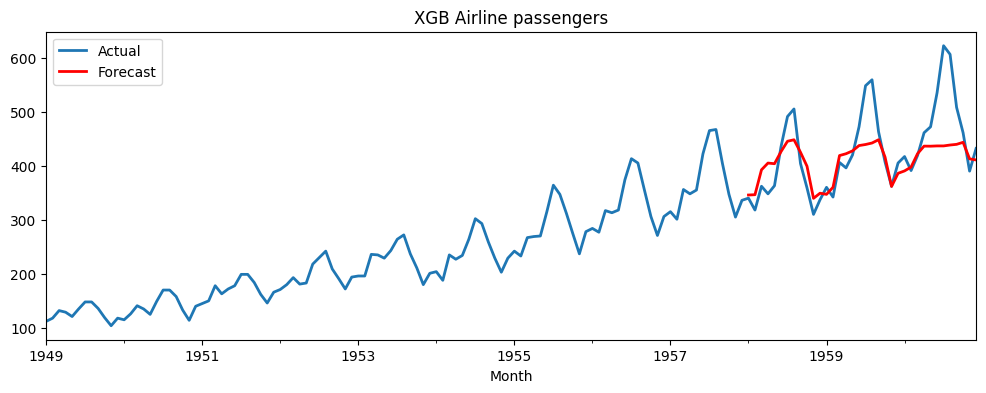

model XGBModel obtains MAPE: 8.43%


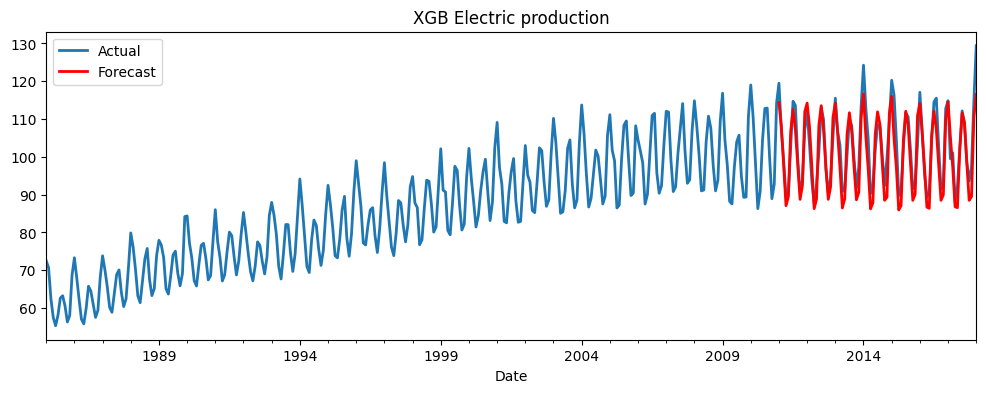

model XGBModel obtains MAPE: 3.45%


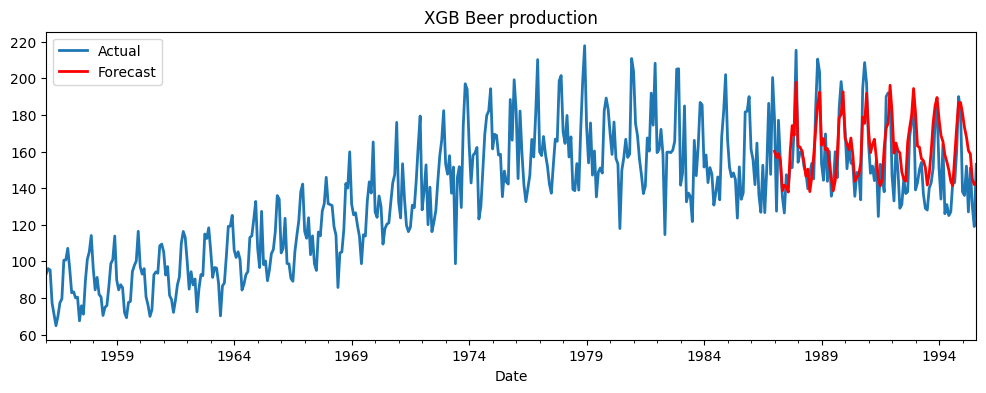

model XGBModel obtains MAPE: 9.21%


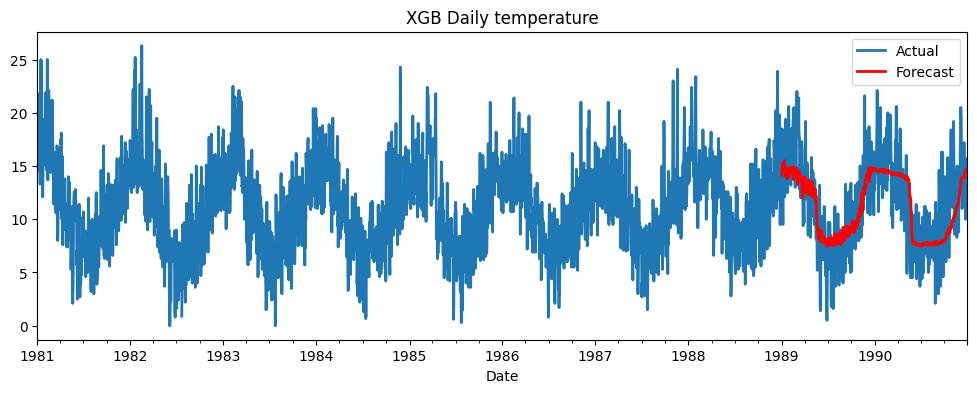

model XGBModel obtains MAPE: 26.67%


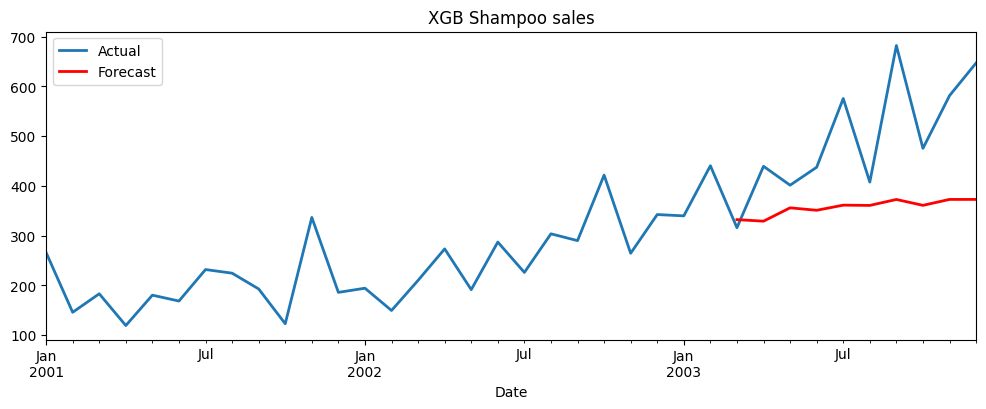

model XGBModel obtains MAPE: 25.78%


In [28]:
# Airline passengers
evaluate_xgb(air_series, air_series_train, air_series_val, lags=12, name="Airline passengers")

# Electric production
evaluate_xgb(electric_series, electric_series_train, electric_series_val, lags=12, name="Electric production")

# Beer production
evaluate_xgb(beer_series, beer_series_train, beer_series_val, lags=12, name="Beer production")

# Daily temperature
evaluate_xgb(temperature_series, temperature_series_train, temperature_series_val, lags=365, name="Daily temperature")

# Shampoo sales
evaluate_xgb(shampoo_series, shampoo_series_train, shampoo_series_val, lags=12, name="Shampoo sales")

### Enrich with date features

In [29]:
# ALternative for regular xgboost package might be
def enrich_with_date_features(df, date_col="Date", include_day=False, include_time=False):
    # Ensure datetime
    df[date_col] = pd.to_datetime(df[date_col])
    
    # Basic date features
    df["quarter"] = df[date_col].dt.quarter
    df["month"] = df[date_col].dt.month
    df["year"] = df[date_col].dt.year

    # Daily features
    if include_day:
        df["dayofmonth"] = df[date_col].dt.day
        df["dayofweek"] = df[date_col].dt.dayofweek
        df["dayofyear"] = df[date_col].dt.dayofyear
        df["sin_day"] = np.sin(2 * np.pi * df["dayofyear"] / 365)
        df["cos_day"] = np.cos(2 * np.pi * df["dayofyear"] / 365)
    
    # Hourly features
    if include_time:
        df["hour"] = df[date_col].dt.hour

    return df


In [30]:
temperature_df_raw = pd.read_csv("data/daily-minimum-temperatures-in-me.csv")
temperature_df_enriched = enrich_with_date_features(temperature_df_raw, date_col="Date", include_day=True)
temperature_df_enriched

,Date,Daily minimum temperatures,quarter,month,year,dayofmonth,dayofweek,dayofyear,sin_day,cos_day
0,1981-01-01,20.7,1,1,1981,1,3,1,1.721336e-02,0.999852
1,1981-01-02,17.9,1,1,1981,2,4,2,3.442161e-02,0.999407
2,1981-01-03,18.8,1,1,1981,3,5,3,5.161967e-02,0.998667
3,1981-01-04,14.6,1,1,1981,4,6,4,6.880243e-02,0.997630
4,1981-01-05,15.8,1,1,1981,5,0,5,8.596480e-02,0.996298
...,...,...,...,...,...,...,...,...,...,...
3645,1990-12-27,14,4,12,1990,27,3,361,-6.880243e-02,0.997630
3646,1990-12-28,13.6,4,12,1990,28,4,362,-5.161967e-02,0.998667
3647,1990-12-29,13.5,4,12,1990,29,5,363,-3.442161e-02,0.999407
3648,1990-12-30,15.7,4,12,1990,30,6,364,-1.721336e-02,0.999852


### Past covariates example

Try to use daily temperature as past covariates to improve beer production prediction

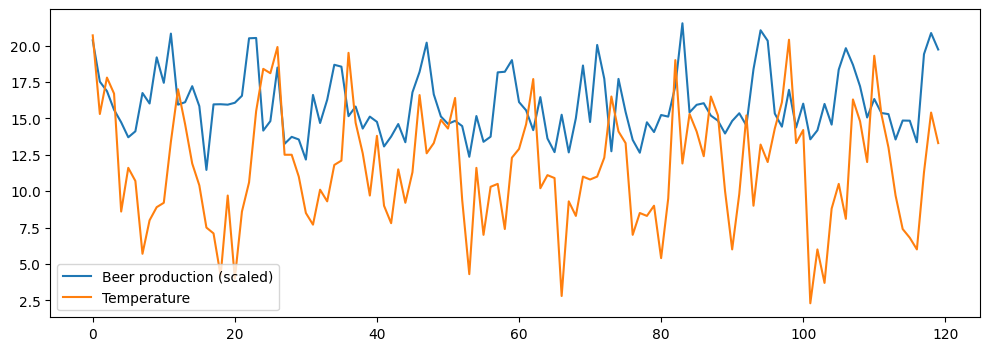

In [31]:
# Slice beer_series to match temperature data period
beer_series_filtered = beer_series.slice(
    pd.Timestamp("1981-01-01"), 
    pd.Timestamp("1990-12-31")
)

# Check
plt.figure(figsize=(12, 4))
plt.plot(beer_series_filtered.values() / 10, label="Beer production (scaled)")
plt.plot(temperature_series.resample("MS").values(), label="Temperature")
plt.legend()
plt.show()

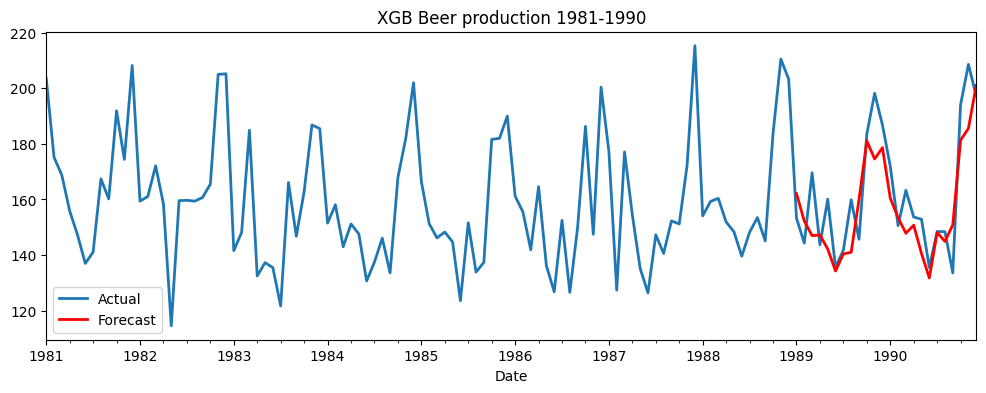

model XGBModel obtains MAPE: 6.05%


In [32]:
# split train / val
beer_train_filtered, beer_val_filtered = beer_series_filtered.split_before(pd.Timestamp("1989-01-01"))

# Evaluate XGB without temperature covarience
evaluate_xgb(beer_series_filtered, beer_train_filtered, beer_val_filtered, lags=12, name="Beer production 1981-1990")

In [33]:
def evaluate_xgb_with_temperature(
    beer_series_filtered,
    temperature_series,
    split_date="1989-01-01",
    lags=12,
    cov_lags=4,
    use_future_covariates=False,
):

    # --- 1. Align temperature to month start ---
    temperature_monthly = temperature_series.resample("MS")

    # --- 2. Train/Val split ---
    beer_train, beer_val = beer_series_filtered.split_before(pd.Timestamp(split_date))

    # --- 3. Extend temperature safely into the future ---
    last_temp = temperature_monthly.last_value()
    future_index = pd.date_range(
        start=temperature_monthly.end_time() + pd.DateOffset(months=1),
        periods=12,
        freq="MS",
    )
    future_temp = TimeSeries.from_times_and_values(
        future_index,
        np.repeat(last_temp, len(future_index)),
    )
    temperature_extended = temperature_monthly.append(future_temp)

    # --- 4. Build correct slices depending on covariate type ---

    if use_future_covariates:
        # future covariates need: val_start -> val_end + cov_lags
        temperature_train = temperature_extended.slice(
            beer_train.start_time(),
            beer_train.end_time(),
        )

        temperature_val = temperature_extended.slice(
            beer_val.start_time(),
            beer_val.end_time() + pd.DateOffset(months=cov_lags),
        )

        model = XGBModel(
            lags=lags,
            lags_future_covariates=(0, cov_lags),
            output_chunk_length=1,
            n_estimators=100,
            max_depth=3,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
        )

        fit_kwargs = {"future_covariates": temperature_train}
        pred_kwargs = {"future_covariates": temperature_val}

    else:
        # past covariates need: history before train AND before val
        temperature_cov = temperature_extended.slice(
            beer_train.start_time() - pd.DateOffset(months=cov_lags),
            beer_val.end_time(),
        )

        temperature_train = temperature_cov.slice(
            beer_train.start_time(),
            beer_train.end_time(),
        )

        temperature_val = temperature_cov.slice(
            beer_val.start_time() - pd.DateOffset(months=cov_lags),
            beer_val.end_time(),
        )

        model = XGBModel(
            lags=lags,
            lags_past_covariates=cov_lags,
            output_chunk_length=1,
            n_estimators=100,
            max_depth=3,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
        )

        fit_kwargs = {"past_covariates": temperature_train}
        pred_kwargs = {"past_covariates": temperature_val}

    # --- 5. Scale target ---
    scaler = Scaler()
    beer_train_scaled = scaler.fit_transform(beer_train)

    # --- 6. Train ---
    model.fit(beer_train_scaled, **fit_kwargs)

    # --- 7. Predict ---
    forecast_scaled = model.predict(len(beer_val), **pred_kwargs)
    forecast = scaler.inverse_transform(forecast_scaled)

    # --- 8. Plot ---
    plt.figure(figsize=(12, 4))
    beer_series_filtered.plot(label="Actual beer production")
    forecast.plot(
        label=f"Forecast with {'future' if use_future_covariates else 'past'} temperature"
    )
    plt.legend()
    plt.show()

    # --- 9. Evaluate ---
    eval_forecast(model, beer_val, forecast)

`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.


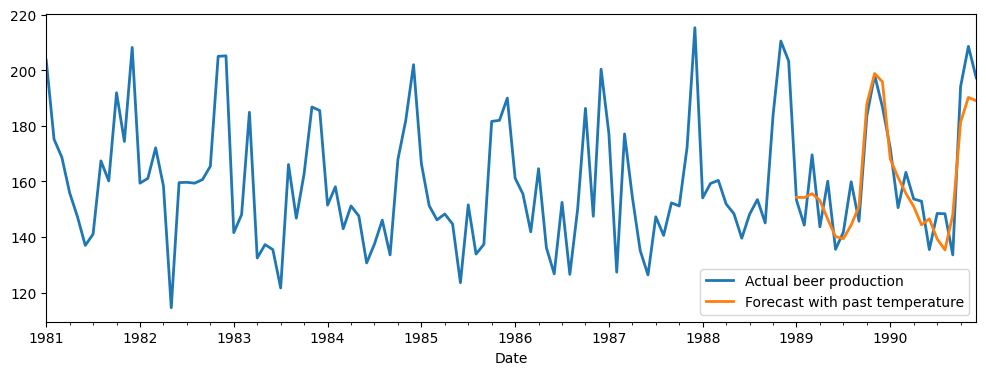

model XGBModel obtains MAPE: 5.49%


In [34]:
evaluate_xgb_with_temperature(
    beer_series_filtered,
    temperature_series,
    use_future_covariates=False,
)

### Future covariates example

Now use daily temperature as future covariates and check beer production prediction

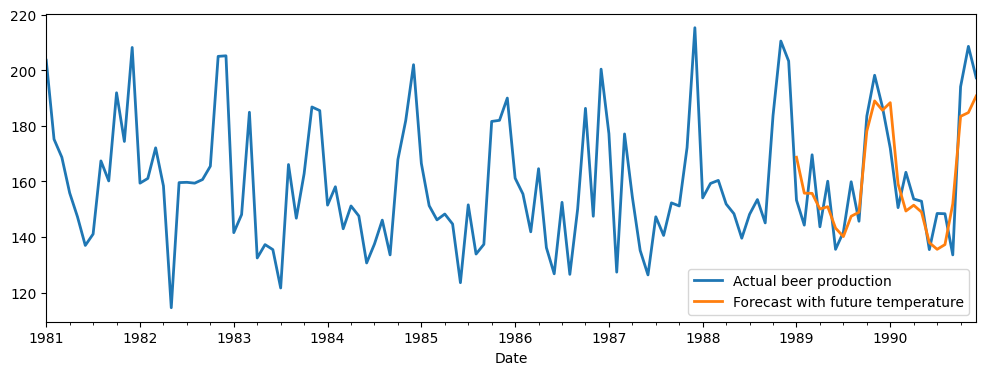

model XGBModel obtains MAPE: 5.88%


In [35]:
evaluate_xgb_with_temperature(
    beer_series_filtered,
    temperature_series,
    use_future_covariates=True,
)

## Exponential Smoothing

**Exponential Smoothing** is a simple forecasting method that gives more weight to recent observations and exponentially less to older ones.

#### Main types of Exponential Smoothing:

- **Simple Exponential Smoothing (SES)** — for series without trend or seasonality.  
  $$ \hat{Y}_t = \alpha Y_{t-1} + (1 - \alpha)\hat{Y}_{t-1} $$
  where $ \alpha $ is the smoothing parameter.

- **Holt’s Linear Trend Model** — captures trend in the series.  
  $$ \hat{Y}_t = \alpha Y_{t-1} + (1 - \alpha)(\hat{Y}_{t-1} + b_{t-1}) $$
  $$ b_t = \beta(\hat{Y}_t - \hat{Y}_{t-1}) + (1 - \beta)b_{t-1} $$
  where $ \beta $ controls trend smoothing.

- **Holt-Winters Seasonal Model** — captures both trend and seasonality.  
  $$ \hat{Y}_t = \alpha(Y_t - S_{t-s}) + (1 - \alpha)(\hat{Y}_{t-1} + b_{t-1}) $$
  $$ b_t = \beta(\hat{Y}_t - \hat{Y}_{t-1}) + (1 - \beta)b_{t-1} $$
  $$ S_t = \gamma(Y_t - \hat{Y}_t) + (1 - \gamma)S_{t-s} $$
  where $ \gamma $ controls seasonal smoothing and $ s $ is the seasonal period.

In [36]:
from darts.utils.utils import ModelMode, SeasonalityMode

def plot_results(series, forecast, title=""):
  plt.figure(figsize=(12, 4))
  series.plot(label='Actual')
  forecast.plot(label='Forecast', color='red')
  plt.title(title)
  plt.legend()
  plt.show()

def fit_and_plot_ext_smooth(series, train, val, name="", seasonal_periods=12, trend=ModelMode.ADDITIVE, seasonal=SeasonalityMode.ADDITIVE):
    model = ExponentialSmoothing(seasonal_periods=seasonal_periods, trend=trend, seasonal=seasonal)
    # Fit the model
    model.fit(train)
    
    # Predict
    forecast = model.predict(len(val))
    
    # Plot results
    plot_results(series, forecast, title=f"ExponentialSmoothing {name}")
    
    # Evaluate
    eval_forecast(model, val, forecast)
    
    # Print info about model type
    trend = "yes" if model.trend is not None else "no"
    seasonal = "yes" if model.seasonal is not None else "no"
    print(f"Model summary for {name}:")
    print(f"- Trend component: {trend}")
    print(f"- Seasonal component: {seasonal}")
    
    if seasonal == "no" and trend == "no":
        print("This is Simple Exponential Smoothing (SES).")
    elif seasonal == "no" and trend == "yes":
        print("This is Holt’s Linear Trend model.")
    elif seasonal == "yes":
        print("This is Holt-Winters Seasonal model.")
    
    print("---\n")

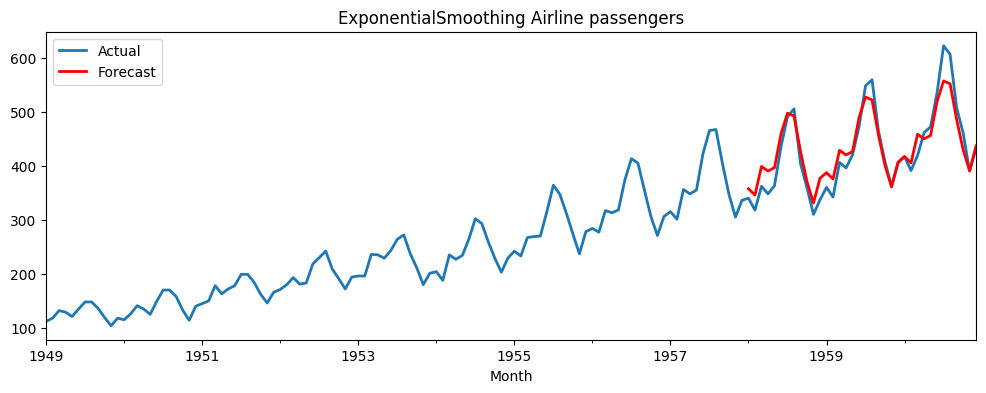

model ExponentialSmoothing obtains MAPE: 5.11%
Model summary for Airline passengers:
- Trend component: yes
- Seasonal component: yes
This is Holt-Winters Seasonal model.
---



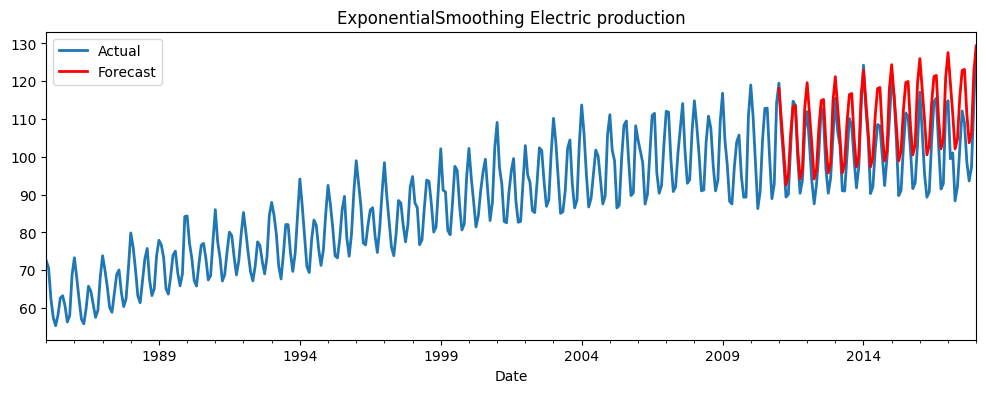

model ExponentialSmoothing obtains MAPE: 7.17%
Model summary for Electric production:
- Trend component: yes
- Seasonal component: yes
This is Holt-Winters Seasonal model.
---



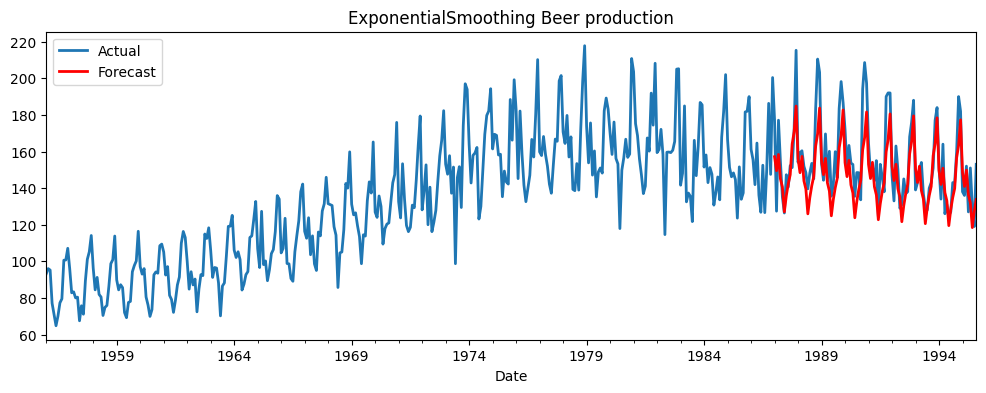

model ExponentialSmoothing obtains MAPE: 6.60%
Model summary for Beer production:
- Trend component: yes
- Seasonal component: yes
This is Holt-Winters Seasonal model.
---



/opt/miniconda3/envs/mlpeople5/lib/python3.11/site-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


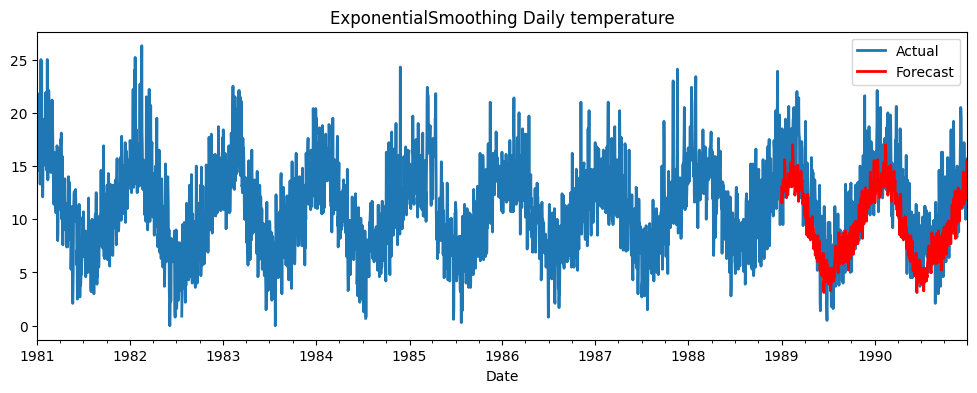

model ExponentialSmoothing obtains MAPE: 27.60%
Model summary for Daily temperature:
- Trend component: no
- Seasonal component: yes
This is Holt-Winters Seasonal model.
---



In [37]:
fit_and_plot_ext_smooth(air_series, air_series_train, air_series_val, name="Airline passengers")
fit_and_plot_ext_smooth(electric_series, electric_series_train, electric_series_val, name="Electric production")
fit_and_plot_ext_smooth(beer_series, beer_series_train, beer_series_val, name="Beer production")
fit_and_plot_ext_smooth(temperature_series, temperature_series_train, temperature_series_val, name="Daily temperature", seasonal_periods=365, trend=None)

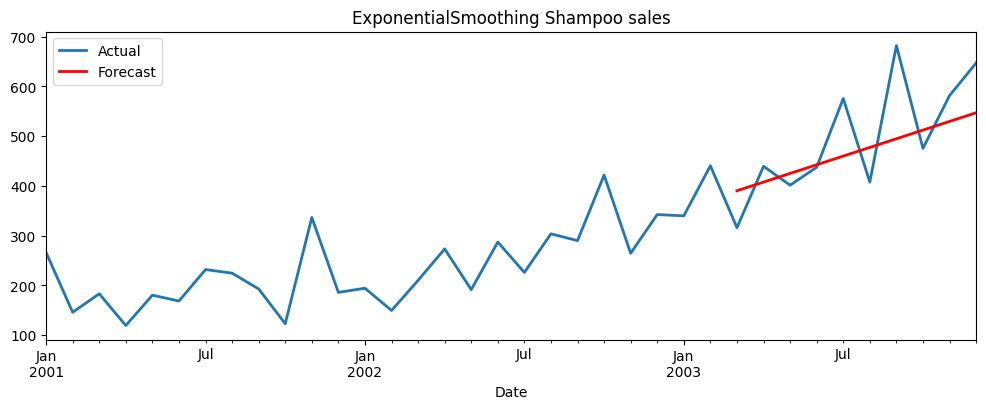

model ExponentialSmoothing obtains MAPE: 13.45%
Model summary for Shampoo sales:
- Trend component: yes
- Seasonal component: no
This is Holt’s Linear Trend model.
---



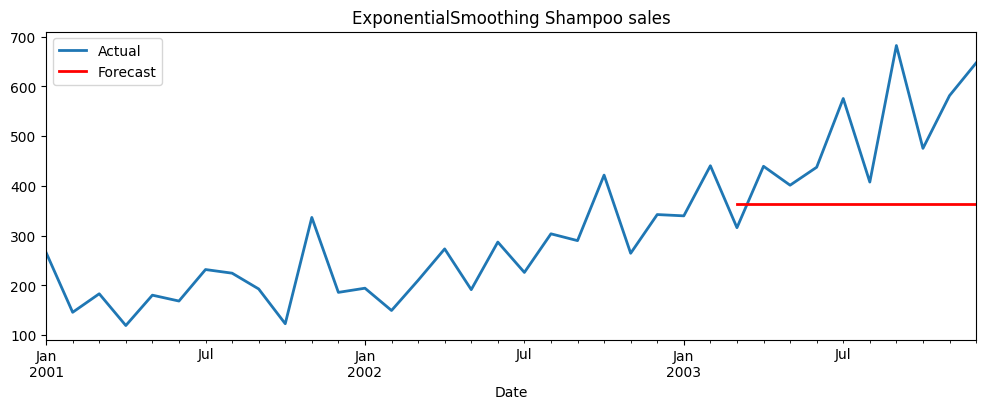

model ExponentialSmoothing obtains MAPE: 25.91%
Model summary for Shampoo sales:
- Trend component: no
- Seasonal component: no
This is Simple Exponential Smoothing (SES).
---



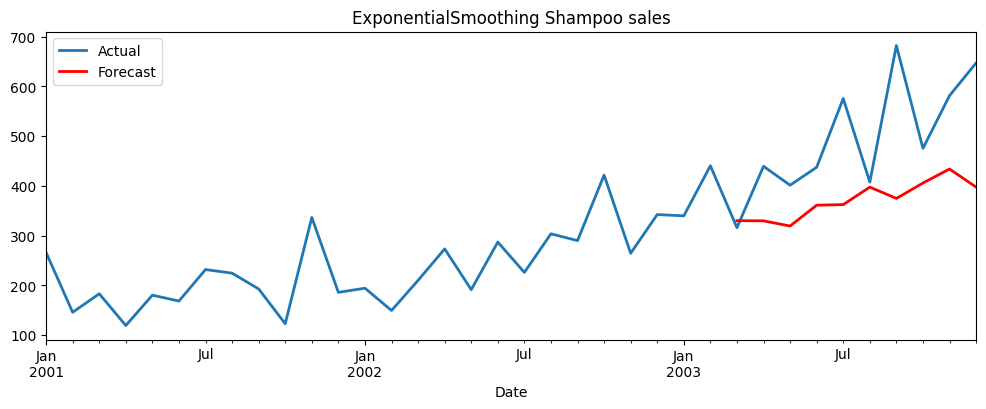

model ExponentialSmoothing obtains MAPE: 23.05%
Model summary for Shampoo sales:
- Trend component: yes
- Seasonal component: yes
This is Holt-Winters Seasonal model.
---



In [38]:
# compare model types for shampoo dataset prediction
fit_and_plot_ext_smooth(shampoo_series, shampoo_series_train, shampoo_series_val, name="Shampoo sales", seasonal=None)
fit_and_plot_ext_smooth(shampoo_series, shampoo_series_train, shampoo_series_val, name="Shampoo sales", seasonal=None, trend=None)
fit_and_plot_ext_smooth(shampoo_series, shampoo_series_train, shampoo_series_val, name="Shampoo sales")

## ARIMA

**ARIMA** (AutoRegressive Integrated Moving Average) combines three components: **AR (autoregression)**, **I (integration/differencing)**, and **MA (moving average)**.

- **AR(p)** – models dependence on previous values:

$$ Y_t = c + \phi_1 Y_{t-1} + \phi_2 Y_{t-2} + \dots + \phi_p Y_{t-p} + \epsilon_t $$

- I(d) – differencing to make the series stationary:

$$ Y_t' = Y_t - Y_{t-1} $$

- MA(q) – models dependence on past forecast errors:

$$ Y_t = c + \epsilon_t + \theta_1 \epsilon_{t-1} + \theta_2 \epsilon_{t-2} + \dots + \theta_q \epsilon_{t-q} $$

ARIMA(p, d, q) combines all:

$$ Y_t = c + \phi_1 Y_{t-1} + \dots + \phi_p Y_{t-p} + \epsilon_t + \theta_1 \epsilon_{t-1} + \dots + \theta_q \epsilon_{t-q} $$

**ARIMA** is widely used due to its simplicity and ability to model non-stationary series.

**Note:** ARIMA struggles with seasonal data (e.g., crop yields, sales with seasonality).  
For seasonal series, use **Seasonal ARIMA (SARIMA / AutoARIMA)** instead.


In [39]:
def fit_and_plot_arima(series, train, val, name="", p=12, d=1, q=1):
    model = ARIMA(p=p, d=d, q=q)
    # Fit the model
    model.fit(train)
    
    # Predict
    forecast = model.predict(len(val))
    
    # Plot results
    plot_results(series, forecast, title=f"ARIMA {name}")
    
    # Evaluate
    eval_forecast(model, val, forecast)

/opt/miniconda3/envs/mlpeople5/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


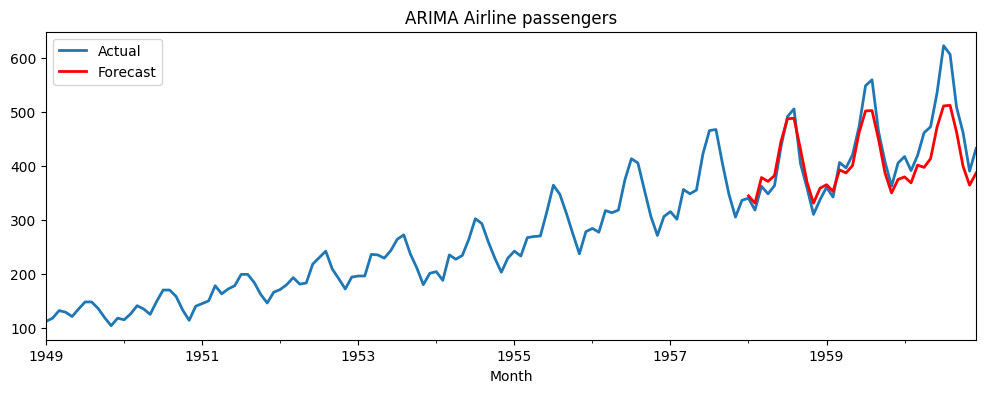

model ARIMA obtains MAPE: 6.56%


/opt/miniconda3/envs/mlpeople5/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


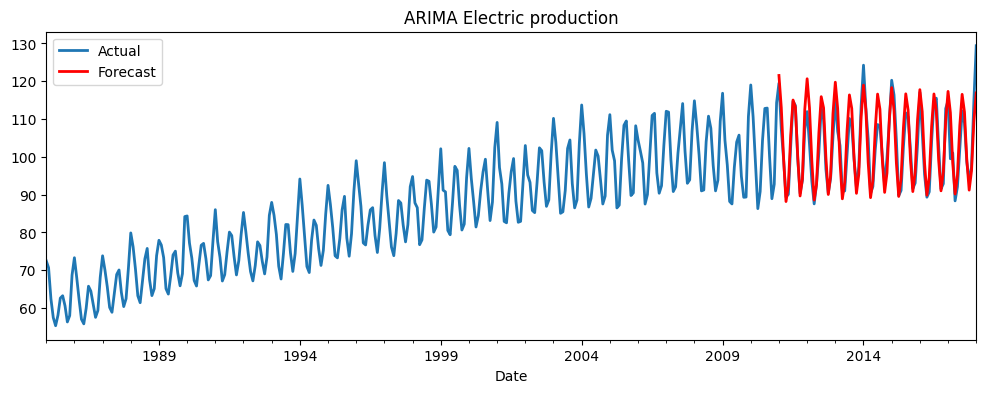

model ARIMA obtains MAPE: 3.17%


/opt/miniconda3/envs/mlpeople5/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


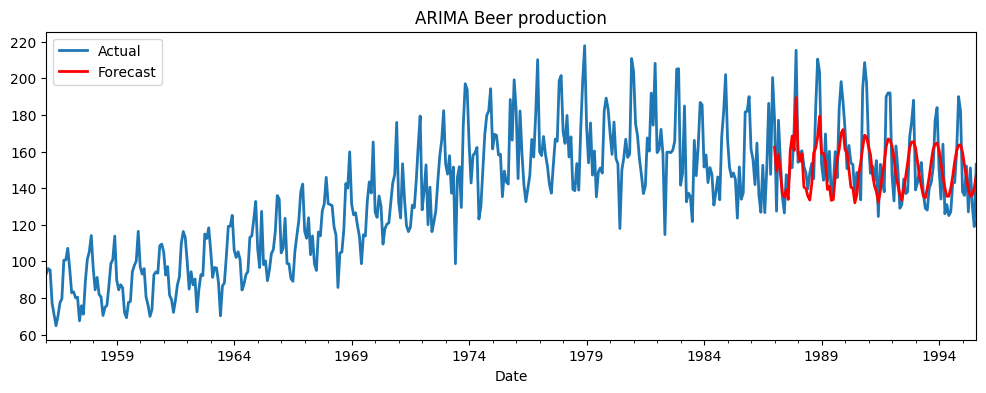

model ARIMA obtains MAPE: 8.18%


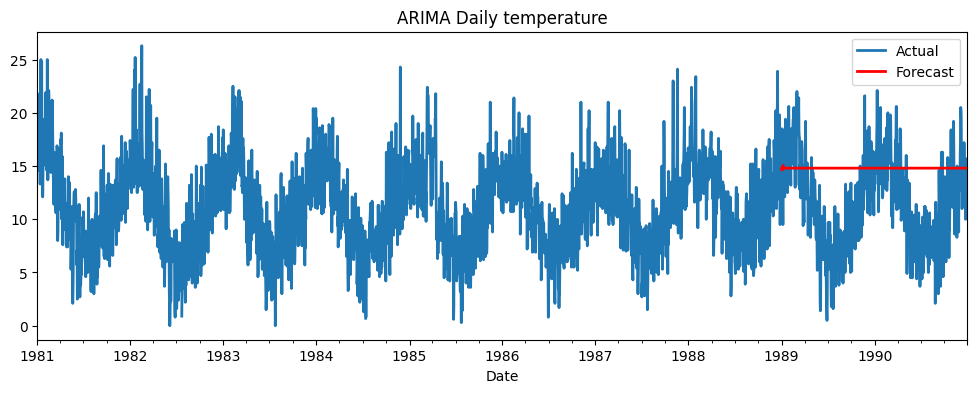

model ARIMA obtains MAPE: 64.35%


In [40]:
fit_and_plot_arima(air_series, air_series_train, air_series_val, name="Airline passengers")
fit_and_plot_arima(electric_series, electric_series_train, electric_series_val, name="Electric production")
fit_and_plot_arima(beer_series, beer_series_train, beer_series_val, name="Beer production")
fit_and_plot_arima(temperature_series, temperature_series_train, temperature_series_val, name="Daily temperature")
# fit_and_plot_arima(shampoo_series, shampoo_series_train, shampoo_series_val, name="Shampoo sales", p=1, d=0, q=0)

## Theta

**Theta** is a simple yet effective time series forecasting model.  
It decomposes the series into **long-term** and **short-term** components and combines their forecasts.

Key ideas:  
- Based on **decomposition**: separates trend and short-term fluctuations.  
- Uses a parameter **θ (theta)** to modify the local curvature of the series:  
  - θ between 0 and 1 → emphasize long-term effects (series “shrinks”)  
  - θ = 0 → series reduces to a linear trend  
  - θ > 1 → emphasize short-term fluctuations (series “stretches”)  

- Creates **Theta-lines** for different θ values. In practice, usually two lines: θ = 0 (trend) and θ = 2 (short-term). Forecasts for each line are combined for the final prediction.

### Main components of Theta:
- **Decomposition**: split series into Theta-lines  
- **Exponential Smoothing**: forecast each Theta-line  
- **Combination**: merge forecasts into final prediction  

Original [paper](https://www.researchgate.net/publication/223049702_The_theta_model_A_decomposition_approach_to_forecasting)  

![](https://miro.medium.com/v2/resize:fit:1400/format:webp/1*koWNcK8OQmbr1CPEhSjWpg.png)  
![](https://miro.medium.com/v2/resize:fit:1400/format:webp/1*x-kbFl6WCVjE9SZWQ7KCKg.png)

In [41]:
from darts.utils.utils import SeasonalityMode

def fit_and_plot_theta(series, train, val, name="", theta=2, season_mode=SeasonalityMode.MULTIPLICATIVE, seasonality_period=12):
    model = Theta(theta=theta, season_mode=season_mode, seasonality_period=seasonality_period)
    # Fit the model
    model.fit(train)
    
    # Predict
    forecast = model.predict(len(val))
    
    # Plot results
    plot_results(series, forecast, title=f"Theta {name}")
    
    # Evaluate
    eval_forecast(model, val, forecast)

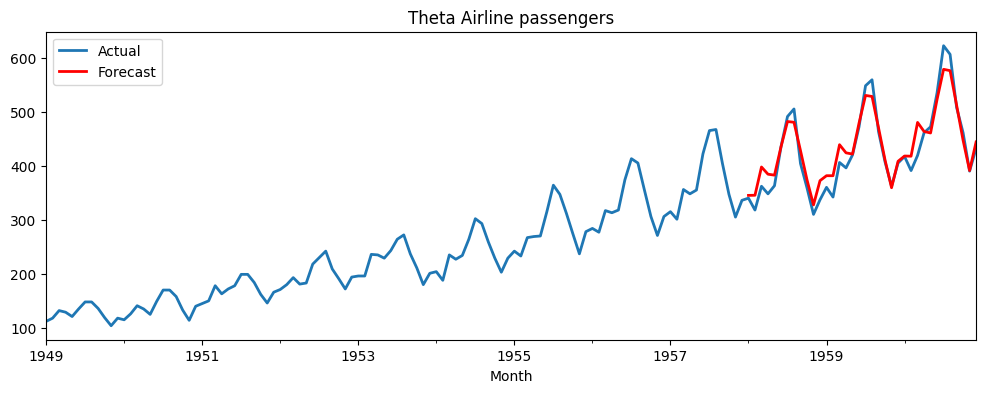

model Theta obtains MAPE: 4.49%


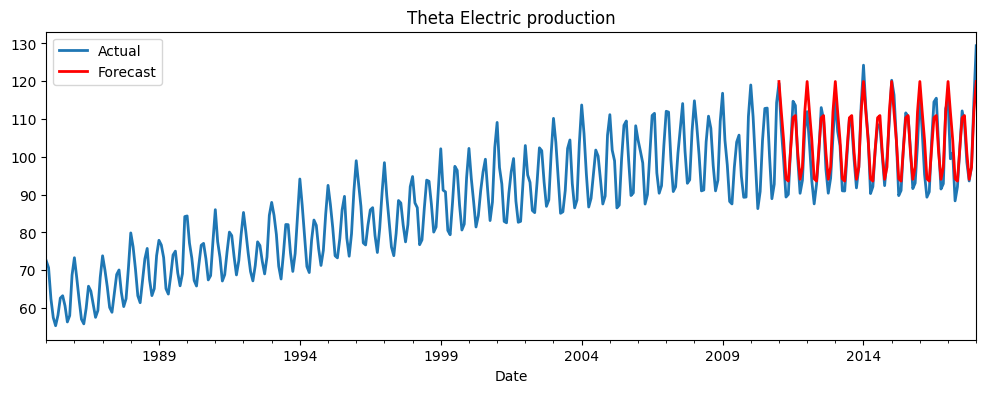

model Theta obtains MAPE: 3.13%


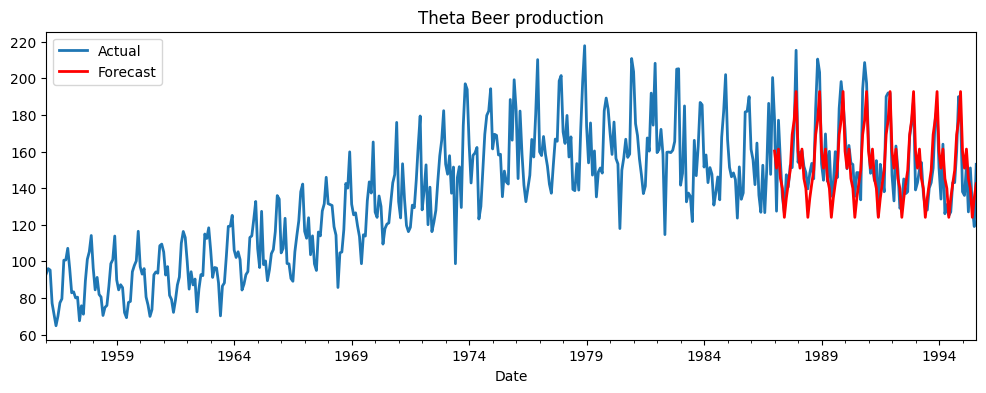

model Theta obtains MAPE: 6.50%


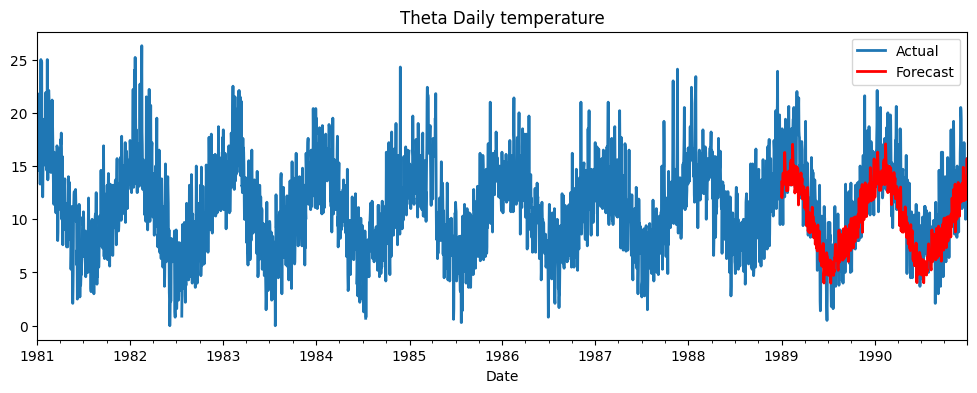

model Theta obtains MAPE: 26.14%


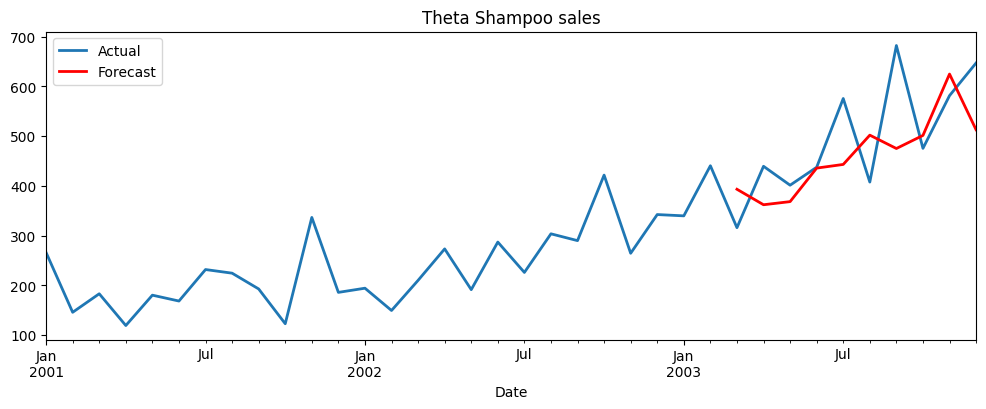

model Theta obtains MAPE: 16.08%


In [42]:
fit_and_plot_theta(air_series, air_series_train, air_series_val, name="Airline passengers", theta=-3)
fit_and_plot_theta(electric_series, electric_series_train, electric_series_val, name="Electric production", theta=1)
fit_and_plot_theta(beer_series, beer_series_train, beer_series_val, name="Beer production", theta=1)
fit_and_plot_theta(temperature_series, temperature_series_train, temperature_series_val, name="Daily temperature", season_mode=SeasonalityMode.ADDITIVE, seasonality_period=365, theta=100)
fit_and_plot_theta(shampoo_series, shampoo_series_train, shampoo_series_val, name="Shampoo sales", theta=-1)